# 📊 World Happiness Report - Exploratory Data Analysis (EDA)

Welcome to the Analysis phase! In this notebook, we dive into the clean dataset generated by our ETL pipeline. The goal is to extract insights regarding global happiness, wealth, health, and how these factors evolved from 2015 to 2019.

We will use **Pandas** for data manipulation and **Seaborn/Matplotlib** for data visualization. 🚀

---

## 1. Setup & Data Loading ⚙️
Importing necessary libraries and loading (`happiness_complete.csv`).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling configuration for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load processed data
processed_path = '../data/processed/happiness_complete.csv'
df = pd.read_csv(processed_path)
df_copy = df.copy()

pd.set_option('display.precision', 2)
df_copy.head()

,Year,Rank,Country,Happiness Score,Economy (GDP),Freedom,Trust (Government),Health
0,2015,1,Switzerland,7.59,1.40,0.67,0.42,0.94
1,2015,2,Iceland,7.56,1.30,0.63,0.14,0.95
2,2015,3,Denmark,7.53,1.33,0.65,0.48,0.87
3,2015,4,Norway,7.52,1.46,0.67,0.37,0.89
4,2015,5,Canada,7.43,1.33,0.63,0.33,0.91


## 2. The Elite & The Bottom: Top 10 Countries 🌍
Who are the happiest and least happy nations on average across all 5 years? Instead of looking at raw numbers, a **Bar Chart** makes the gap between countries much clearer.

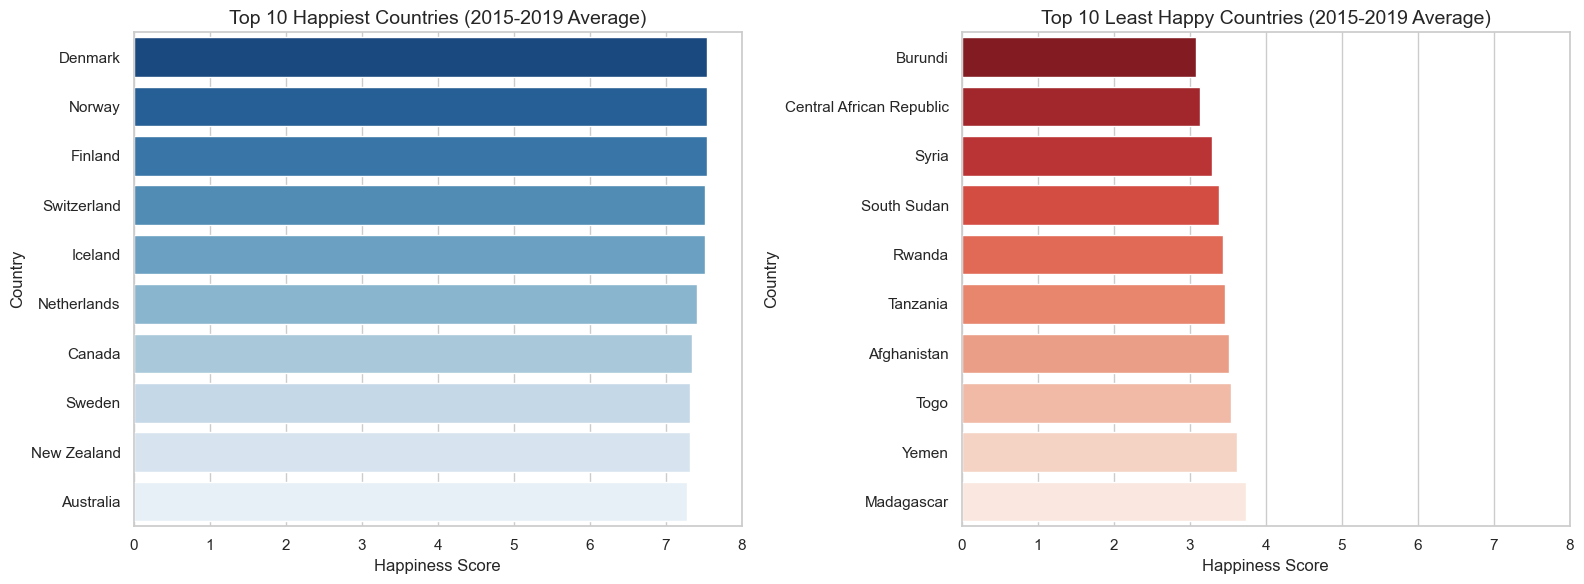

In [20]:
# Calculate the 5-year average for each country
average_happiness = df_copy.groupby('Country')['Happiness Score'].mean().sort_values(ascending=False)

top_10 = average_happiness.head(10)
bottom_10 = average_happiness.tail(10).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Chart - Azul didático para países felizes
sns.barplot(x=top_10.values, y=top_10.index, ax=axes[0], hue=top_10.index, palette="Blues_r", legend=False)
axes[0].set_title('Top 10 Happiest Countries (2015-2019 Average)', fontsize=14)
axes[0].set_xlabel('Happiness Score')
axes[0].set_xlim(0, 8)

# Bottom 10 Chart - Vermelho/Rosa didático para países menos felizes
sns.barplot(x=bottom_10.values, y=bottom_10.index, ax=axes[1], hue=bottom_10.index, palette="Reds_r", legend=False)
axes[1].set_title('Top 10 Least Happy Countries (2015-2019 Average)', fontsize=14)
axes[1].set_xlabel('Happiness Score')
axes[1].set_xlim(0, 8)

plt.tight_layout()
plt.show()

## 3. Wealth vs. Happiness: Does Money Buy Smiles? 💰
To understand the relationship between a country's GDP and its happiness, a **Scatter Plot** is the ideal tool. It shows the distribution and highlights if there is a positive correlation.

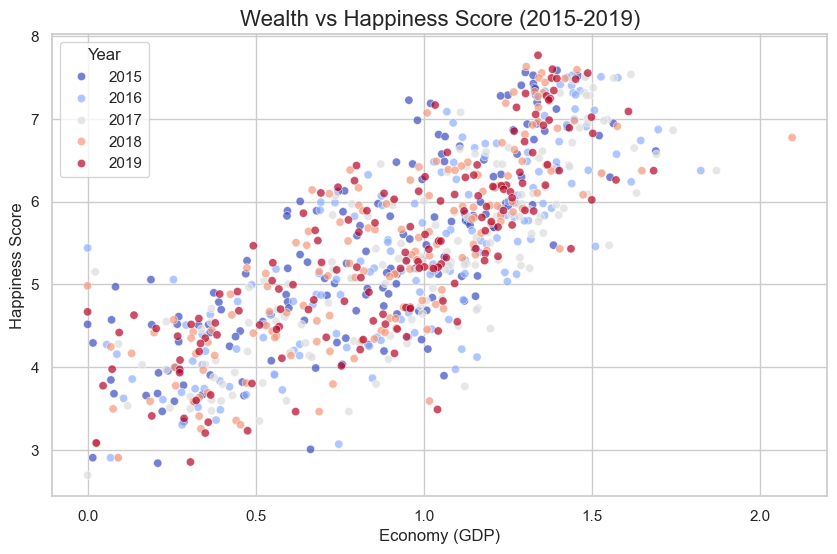

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='Economy (GDP)', y='Happiness Score', hue='Year', palette='coolwarm', alpha=0.7)
plt.title('Wealth vs Happiness Score (2015-2019)', fontsize=16)
plt.xlabel('Economy (GDP)')
plt.ylabel('Happiness Score')
plt.show()

**Insight:** There is a clear upward trend. Countries with higher GDP tend to have higher Happiness Scores. However, at the very top (GDP > 1.4), happiness scores vary widely, suggesting money isn't the *only* factor.

## 4. The Big Picture: Correlation Matrix 🔗
Let's map out how all numerical variables relate to each other. A **Heatmap** visually represents the Pearson correlation matrix. Values closer to 1 indicate a strong positive relationship.

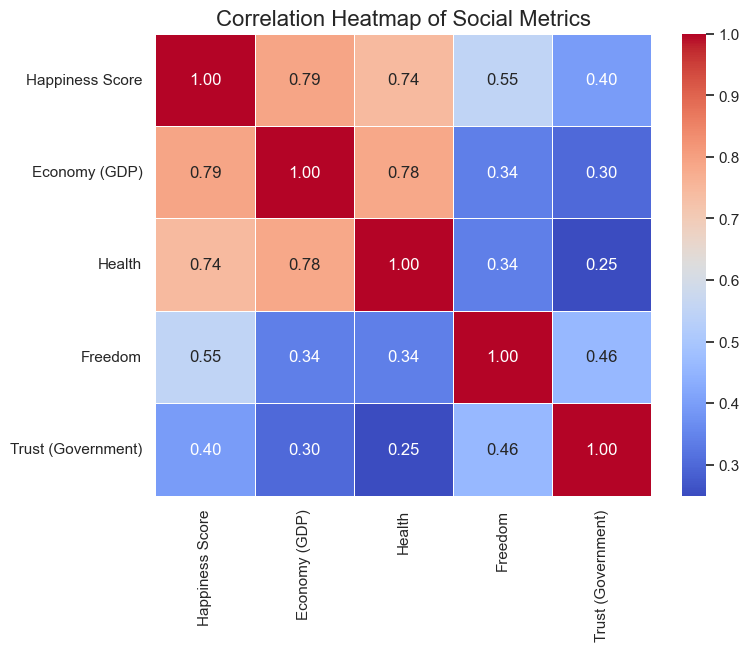

In [22]:
columns_to_correlate = ['Happiness Score', 'Economy (GDP)', 'Health', 'Freedom', 'Trust (Government)']
correlation = df_copy[columns_to_correlate].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Social Metrics', fontsize=16)
plt.show()

**Insight:** Economy (0.79) and Health (0.74) are the strongest predictors of Happiness. Interestingly, Trust in Government has a relatively low correlation (0.40) with Happiness on a global scale.

## 5. Global Trends: Happiness & Trust Over Time 📈
Instead of calculating the sum and dividing manually for each year, we can automate this using Pandas' `.groupby()` function. Let's see how the global averages for Happiness and Trust evolved.

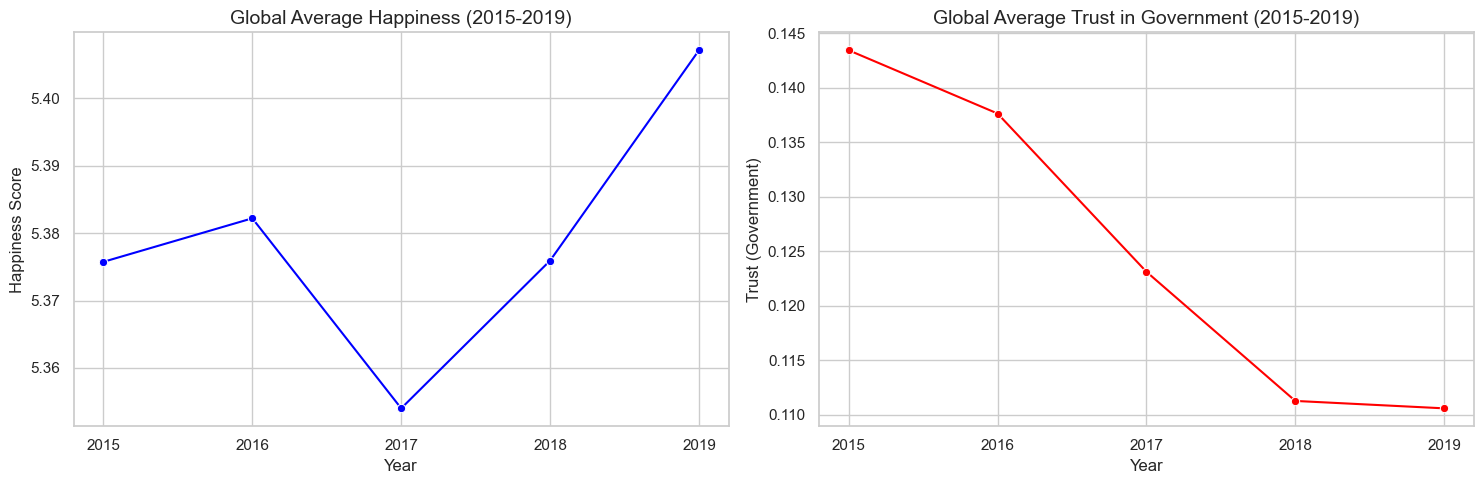

In [23]:
# Grouping data by Year and calculating the mean
yearly_trends = df_copy.groupby('Year')[['Happiness Score', 'Trust (Government)']].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Global Happiness Trend
sns.lineplot(data=yearly_trends, x=yearly_trends.index, y='Happiness Score', marker='o', ax=axes[0], color='blue')
axes[0].set_title('Global Average Happiness (2015-2019)', fontsize=14)
axes[0].set_xticks([2015, 2016, 2017, 2018, 2019])

# Global Trust Trend
sns.lineplot(data=yearly_trends, x=yearly_trends.index, y='Trust (Government)', marker='o', ax=axes[1], color='red')
axes[1].set_title('Global Average Trust in Government (2015-2019)', fontsize=14)
axes[1].set_xticks([2015, 2016, 2017, 2018, 2019])

plt.tight_layout()
plt.show()

**Insight:** While global happiness remained relatively stable (hovering around 5.37 - 5.40), the global trust in government saw a sharp decline from 2015 to 2019.

## 6. Spotlight: Brazil's Evolution 🇧🇷
Finally, let's isolate the data for Brazil. Using safe querying methods prevents `IndexErrors` (which happen when a specific row isn't found). Let's plot Brazil's journey over the 5 years.

Brazil's 5-Year Average Happiness Score: 6.66



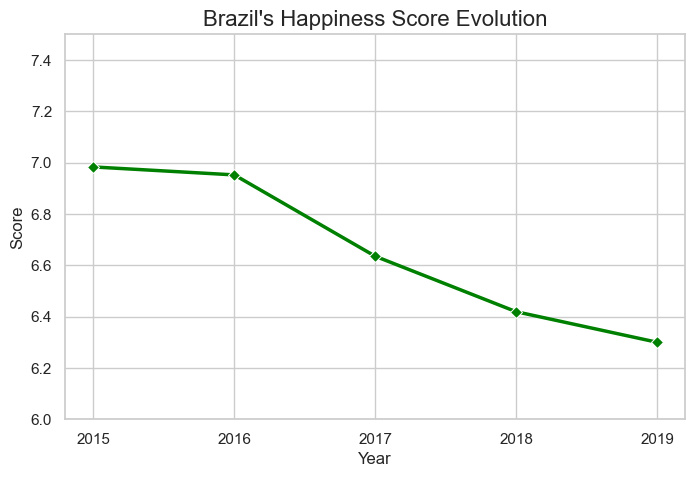

In [24]:
# Safe filtering for Brazil
brazil_data = df_copy[df_copy['Country'] == 'Brazil']

# Calculate the safe 5-year mean
brazil_mean = brazil_data['Happiness Score'].mean()
print(f"Brazil's 5-Year Average Happiness Score: {brazil_mean:.2f}\n")

# Plotting Brazil's performance
plt.figure(figsize=(8, 5))
sns.lineplot(data=brazil_data, x='Year', y='Happiness Score', marker='D', color='green', linewidth=2.5)
plt.title("Brazil's Happiness Score Evolution", fontsize=16)
plt.xticks([2015, 2016, 2017, 2018, 2019])
plt.ylabel('Score')
plt.ylim(6.0, 7.5)
plt.show()